# Inter-annotator Agreement (Cohen's Kappa)

Compares annotations from three sources:
- **sample.json** — original multi-annotator dataset (JSONL, per-tweet annotator lists)
- **jmperez.json** — manual annotations by jmperez (boolean labels)
- **sample_labeled_llm.json** — LLM annotations via OpenAI GPT-4o-mini (boolean labels)

In [1]:
%matplotlib inline

import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.metrics import cohen_kappa_score

## Load data

In [2]:
DATA_DIR = Path("../data")

def load_json(path: Path, lines: bool = False):
    path = str(path)
    if path.endswith(".jsonl") or lines:     
        records = []
        with open(path) as f:
            for line in f:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
        return records
    else:
        return json.load(open(path))

# sample.json is JSONL (one record per line)
sample = load_json(DATA_DIR / "sample.json", lines=True)

# jmperez.json and any other human annotator files with the same structure
human_files = {
    Path(f).stem: load_json(f)
    for f in [DATA_DIR / "jmperez.json"]
}
llm_records = json.load(open(DATA_DIR / "sample_labeled_llm.json"))

print(f"sample.json:            {len(sample)} items")
for name, records in human_files.items():
    print(f"{name}.json:  {len(records)} items")
print(f"sample_labeled_llm.json:{len(llm_records)} items")

sample.json:            74 items
jmperez.json:  75 items
sample_labeled_llm.json:74 items


## Explore data structure

In [3]:
print("=== sample.json keys ===")
print(list(sample[0].keys()))
print("\nExample annotators field:", sample[0]["annotators"])
print("Example HATEFUL field:",    sample[0]["HATEFUL"])

print("\n=== human annotator keys ===")
for name, records in human_files.items():
    print(f"{name}:", list(records[0].keys()))

print("\n=== LLM keys ===")
print(list(llm_records[0].keys()))

=== sample.json keys ===
['text', 'article_id', 'annotators', 'HATEFUL', 'CALLS', 'WOMEN', 'LGBTI', 'RACISM', 'CLASS', 'POLITICS', 'DISABLED', 'APPEARANCE', 'CRIMINAL', 'tweet_id', 'user_id', 'id', 'is_hateful', 'categories', 'calls_to_action', 'min_label', 'context_tweet', 'title', 'body']

Example annotators field: ['annotator_6', 'annotator_5', 'annotator_2']
Example HATEFUL field: ['annotator_5', 'annotator_2']

=== human annotator keys ===
jmperez: ['id', 'tweet_id', 'article_id', 'text', 'annotator', 'HATEFUL', 'OFFENSIVE', 'CALLS', 'WOMEN', 'LGBTI', 'RACISM', 'CLASS', 'POLITICS', 'DISABLED', 'APPEARANCE', 'CRIMINAL']

=== LLM keys ===
['id', 'tweet_id', 'article_id', 'text', 'annotator', 'HATEFUL', 'OFFENSIVE', 'CALLS', 'categories']


## ID overlap

In [4]:
sample_ids  = {r["id"] for r in sample}
llm_ids     = {r["id"] for r in llm_records}
human_ids   = {name: {r["id"] for r in records} for name, records in human_files.items()}

all_sets = [sample_ids, llm_ids] + list(human_ids.values())
common_ids = sorted(set.intersection(*all_sets))

print(f"sample IDs:  {len(sample_ids)}")
print(f"LLM IDs:     {len(llm_ids)}")
for name, ids in human_ids.items():
    print(f"{name} IDs: {len(ids)}")
print(f"\nCommon IDs (all sources): {len(common_ids)}")

sample IDs:  74
LLM IDs:     74
jmperez IDs: 75

Common IDs (all sources): 74


## Build unified annotation matrix

Labels covered:
- **HATEFUL** — all sources
- **OFFENSIVE** — human annotators + LLM only (not in original sample)
- **CALLS** — all sources
- **Category labels** (WOMEN, LGBTI, RACISM, CLASS, POLITICS, DISABLED, APPEARANCE, CRIMINAL) — sample + human annotators; LLM provides a `categories` list that is expanded

For `sample.json`, each label field contains a **list of annotator IDs** who assigned that label, so we expand them into per-annotator boolean columns.

In [5]:
SAMPLE_LABELS   = ["HATEFUL", "CALLS", "WOMEN", "LGBTI", "RACISM",
                   "CLASS", "POLITICS", "DISABLED", "APPEARANCE", "CRIMINAL"]
HUMAN_LABELS    = ["HATEFUL", "OFFENSIVE", "CALLS", "WOMEN", "LGBTI", "RACISM",
                   "CLASS", "POLITICS", "DISABLED", "APPEARANCE", "CRIMINAL"]
LLM_BOOL_LABELS = ["HATEFUL", "OFFENSIVE", "CALLS"]
LLM_CAT_LABELS  = ["WOMEN", "LGBTI", "RACISM", "CLASS", "POLITICS",
                   "DISABLED", "APPEARANCE", "CRIMINAL"]

# Index: tweet id
index = common_ids

# ── sample.json: expand per-annotator ──────────────────────────────────────
sample_by_id = {r["id"]: r for r in sample}

all_sample_annotators = set()
for r in sample:
    all_sample_annotators.update(r["annotators"])
all_sample_annotators = sorted(all_sample_annotators)

sample_frames = {}
for ann in all_sample_annotators:
    rows = {}
    for tid in index:
        r = sample_by_id[tid]
        if ann not in r["annotators"]:
            rows[tid] = {lbl: np.nan for lbl in SAMPLE_LABELS}
        else:
            rows[tid] = {lbl: (ann in r.get(lbl, [])) for lbl in SAMPLE_LABELS}
    sample_frames[ann] = pd.DataFrame.from_dict(rows, orient="index")

# ── human annotators (jmperez, etc.) ────────────────────────────────────────
human_frames = {}
for name, records in human_files.items():
    by_id = {r["id"]: r for r in records}
    rows = {}
    for tid in index:
        if tid in by_id:
            rows[tid] = {lbl: by_id[tid].get(lbl) for lbl in HUMAN_LABELS}
        else:
            rows[tid] = {lbl: np.nan for lbl in HUMAN_LABELS}
    human_frames[name] = pd.DataFrame.from_dict(rows, orient="index")

# ── LLM annotations ─────────────────────────────────────────────────────────
llm_by_id = {r["id"]: r for r in llm_records}
llm_rows = {}
for tid in index:
    r = llm_by_id[tid]
    row = {lbl: r[lbl] for lbl in LLM_BOOL_LABELS}
    cats = set(r.get("categories", []))
    for lbl in LLM_CAT_LABELS:
        row[lbl] = lbl in cats
    llm_rows[tid] = row
llm_frame = pd.DataFrame.from_dict(llm_rows, orient="index")

print("Sample annotators found:", all_sample_annotators)
print("Human annotator files:",   list(human_frames.keys()))
print("\nFrames built successfully.")

Sample annotators found: ['annotator_1', 'annotator_2', 'annotator_3', 'annotator_4', 'annotator_5', 'annotator_6']
Human annotator files: ['jmperez']

Frames built successfully.


## Kappa helper

In [6]:
def kappa_pair(y1: pd.Series, y2: pd.Series) -> tuple[float, int] | tuple[None, int]:
    """Cohen's kappa for two boolean series, ignoring NaN. Returns (kappa, n_items)."""
    mask = y1.notna() & y2.notna()
    n = int(mask.sum())
    if n < 2:
        return None, n
    a = y1[mask].astype(int).values
    b = y2[mask].astype(int).values
    if len(set(a)) == 1 and len(set(b)) == 1:
        return (1.0 if np.array_equal(a, b) else 0.0), n
    return cohen_kappa_score(a, b), n


MIN_N = 15  # minimum overlapping annotations to report a kappa


def pairwise_kappa(frames: dict[str, pd.DataFrame], label: str) -> pd.DataFrame:
    """Compute pairwise kappa for a given label across all annotator frames (n >= MIN_N only)."""
    names = list(frames.keys())
    rows = []
    for i, a in enumerate(names):
        for b in names[i + 1:]:
            if label not in frames[a].columns or label not in frames[b].columns:
                continue
            k, n = kappa_pair(frames[a][label], frames[b][label])
            if k is None or n < MIN_N:
                continue
            rows.append({"annotator_a": a, "annotator_b": b, "kappa": k, "n": n})
    return pd.DataFrame(rows).sort_values("kappa", ascending=False).reset_index(drop=True)


def pair_type(a: str, b: str) -> str:
    return "vs. openai" if "openai" in (a, b) else "human–human"


def displot_kappas(df: pd.DataFrame, title: str, ax=None):
    """KDE + rug distribution of kappa values, blue=human–human, red=vs. openai."""
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3.5))

    groups = {"human–human": "blue", "vs. openai": "red"}
    x = np.linspace(-0.1, 1.1, 400)
    rug_y = -0.06

    for label, color in groups.items():
        vals = df[df["type"] == label]["kappa"].values
        if len(vals) == 0:
            continue
        if len(vals) > 1:
            kde = gaussian_kde(vals, bw_method=0.25)
            y = kde(x)
            ax.plot(x, y, color=color, lw=2, label=f"{label}  (n={len(vals)})")
            ax.fill_between(x, y, alpha=0.15, color=color)
        ax.vlines(vals, rug_y - 0.03, rug_y + 0.03, color=color, alpha=0.7, lw=1.5)

    ax.set_xlim(0, 1)
    ax.set_ylim(rug_y - 0.06)
    ax.axvline(0, color="grey", lw=0.8, ls="--")
    ax.set_xlabel("Cohen's κ")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend(fontsize=8)
    return ax


## HATEFUL — all annotators

In [7]:
all_frames = {**sample_frames, **human_frames, "openai": llm_frame}

kappa_hateful = pairwise_kappa(all_frames, "HATEFUL")
print("Pairwise kappa — HATEFUL")
print(kappa_hateful.to_string(index=False))

Pairwise kappa — HATEFUL
annotator_a annotator_b    kappa  n
annotator_2     jmperez 0.632653 45
annotator_5     jmperez 0.617284 31
annotator_2 annotator_5 0.594595 15
annotator_3     jmperez 0.564103 17
annotator_1      openai 0.557377 36
annotator_1     jmperez 0.555556 36
annotator_1 annotator_2 0.522388 16
annotator_6     jmperez 0.491525 45
annotator_1 annotator_6 0.473684 15
annotator_2 annotator_6 0.469194 28
annotator_5 annotator_6 0.380435 19
    jmperez      openai 0.363386 74
annotator_3      openai 0.287425 17
annotator_2      openai 0.211982 45
annotator_5      openai 0.088235 31
annotator_6      openai 0.019608 45


### Summary: jmperez and openai vs. sample annotators

In [8]:
focal = list(human_frames.keys()) + ["openai"]

rows = []
for ann in all_sample_annotators:
    for focal_name in focal:
        k, n = kappa_pair(sample_frames[ann]["HATEFUL"], all_frames[focal_name]["HATEFUL"])
        if k is not None and n >= MIN_N:
            rows.append({"annotator_a": ann, "annotator_b": focal_name, "kappa": k, "n": n})

df_focal = pd.DataFrame(rows)
print("HATEFUL kappa — jmperez / openai vs. each sample annotator (n >= 15)\n")
print(df_focal.to_string(index=False))


HATEFUL kappa — jmperez / openai vs. each sample annotator (n >= 15)

annotator_a annotator_b    kappa  n
annotator_1     jmperez 0.555556 36
annotator_1      openai 0.557377 36
annotator_2     jmperez 0.632653 45
annotator_2      openai 0.211982 45
annotator_3     jmperez 0.564103 17
annotator_3      openai 0.287425 17
annotator_5     jmperez 0.617284 31
annotator_5      openai 0.088235 31
annotator_6     jmperez 0.491525 45
annotator_6      openai 0.019608 45


## Other labels — jmperez vs. openai

In [9]:
shared_labels = sorted(
    set(human_frames["jmperez"].columns) & set(llm_frame.columns)
)

rows = []
for lbl in shared_labels:
    k, n = kappa_pair(human_frames["jmperez"][lbl], llm_frame[lbl])
    if k is not None and n >= MIN_N:
        rows.append({"label": lbl, "kappa": k, "n": n})

df_jmperez_vs_llm = pd.DataFrame(rows).sort_values("kappa", ascending=False).reset_index(drop=True)
print("jmperez vs openai (n >= 15)")
print(df_jmperez_vs_llm.to_string(index=False))


jmperez vs openai (n >= 15)
     label     kappa  n
     LGBTI  0.793296 74
    RACISM  0.748727 74
     CLASS  0.509284 74
  CRIMINAL  0.408946 74
     CALLS  0.363897 74
   HATEFUL  0.363386 74
  POLITICS  0.319853 74
     WOMEN  0.281553 74
 OFFENSIVE  0.098560 74
  DISABLED -0.013699 74
APPEARANCE -0.023041 74


## Distribution of Cohen's κ — category labels

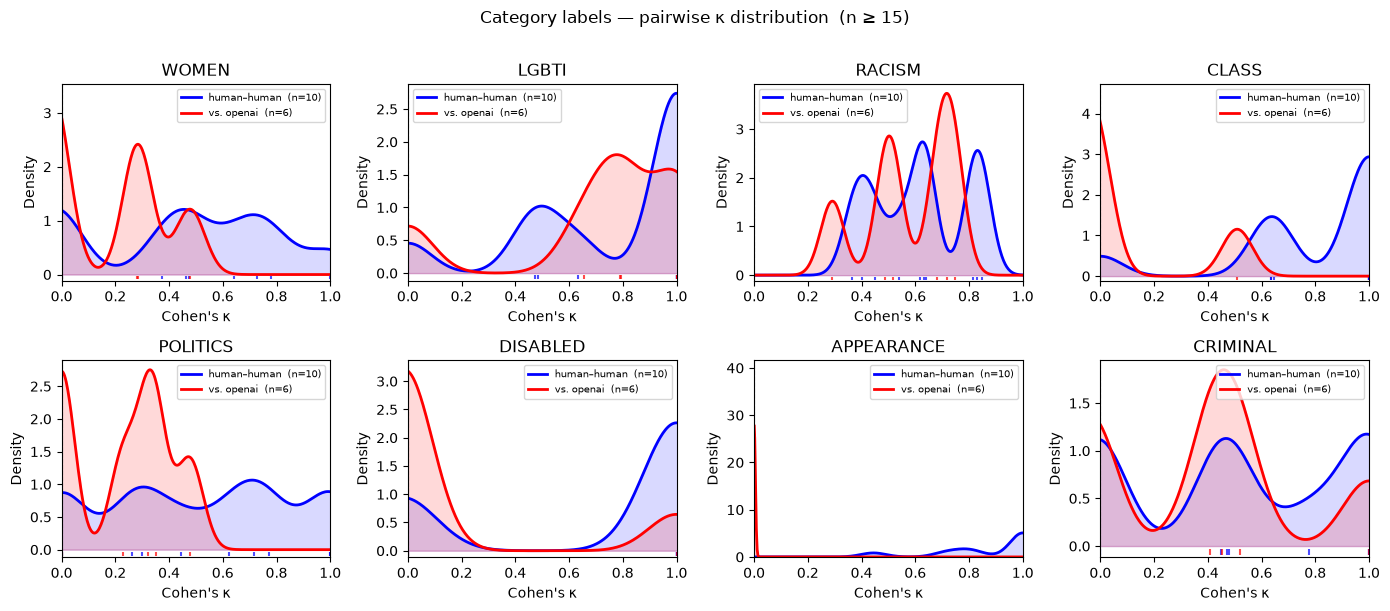

In [10]:
cat_labels = ["WOMEN", "LGBTI", "RACISM", "CLASS", "POLITICS",
               "DISABLED", "APPEARANCE", "CRIMINAL"]
cat_frames = {**sample_frames, **human_frames, "openai": llm_frame}

rows = []
for lbl in cat_labels:
    df_lbl = pairwise_kappa(cat_frames, lbl)
    df_lbl["label"] = lbl
    rows.append(df_lbl)

df_cat = pd.concat(rows, ignore_index=True)
df_cat["type"] = df_cat.apply(
    lambda r: "vs. openai" if "openai" in (r["annotator_a"], r["annotator_b"]) else "human–human",
    axis=1,
)

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=False)
for ax, lbl in zip(axes.flat, cat_labels):
    subset = df_cat[df_cat["label"] == lbl]
    displot_kappas(subset, lbl, ax=ax)
    ax.legend(fontsize=7)

plt.suptitle(f"Category labels — pairwise κ distribution  (n ≥ {MIN_N})", y=1.01)
plt.tight_layout()
plt.show()


## Distribution of Cohen's κ — HATEFUL

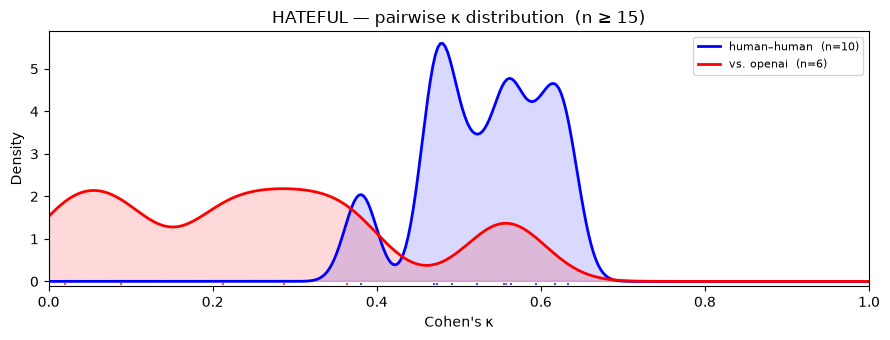

In [11]:
df_hateful = pairwise_kappa(all_frames, "HATEFUL")
df_hateful["type"] = df_hateful.apply(lambda r: pair_type(r["annotator_a"], r["annotator_b"]), axis=1)

fig, ax = plt.subplots(figsize=(9, 3.5))
displot_kappas(df_hateful, f"HATEFUL — pairwise κ distribution  (n ≥ {MIN_N})", ax=ax)
plt.tight_layout()
plt.show()


## Label prevalence per annotator

In [12]:
all_labels = ["HATEFUL", "OFFENSIVE", "CALLS"] + cat_labels

prev_rows = []
for name, frame in all_frames.items():
    for lbl in all_labels:
        if lbl in frame.columns:
            col = frame[lbl].dropna()
            prev_rows.append({"annotator": name, "label": lbl,
                               "positive_rate": col.mean(), "n": len(col)})

df_prev = pd.DataFrame(prev_rows)
pivot = df_prev.pivot(index="annotator", columns="label", values="positive_rate")
print("Positive rate per annotator per label")
print(pivot.round(3).to_string())

Positive rate per annotator per label
label        APPEARANCE  CALLS  CLASS  CRIMINAL  DISABLED  HATEFUL  LGBTI  OFFENSIVE  POLITICS  RACISM  WOMEN
annotator                                                                                                    
annotator_1       0.056  0.028  0.000     0.028     0.000    0.278  0.056        NaN     0.028   0.111  0.028
annotator_2       0.133  0.044  0.044     0.111     0.022    0.556  0.067        NaN     0.000   0.156  0.044
annotator_3       0.235  0.118  0.118     0.000     0.059    0.647  0.000        NaN     0.059   0.294  0.000
annotator_4       0.000  0.000  0.000     0.000     0.000    0.286  0.000        NaN     0.000   0.143  0.143
annotator_5       0.065  0.065  0.065     0.129     0.000    0.484  0.032        NaN     0.097   0.097  0.032
annotator_6       0.089  0.044  0.067     0.022     0.022    0.400  0.022        NaN     0.089   0.044  0.067
jmperez           0.068  0.095  0.081     0.068     0.014    0.554  0.041      0.1

## Unified HATEFUL label table\n\nOne row per tweet, one column per annotator. `NaN` = annotator did not cover that tweet.

In [13]:
HATE_CATS = ["WOMEN", "LGBTI", "RACISM", "CLASS", "POLITICS",
             "DISABLED", "APPEARANCE", "CRIMINAL"]

sample_by_id_full = {r["id"]: r for r in sample}
jmperez_by_id     = {r["id"]: r for r in human_files["jmperez"]}
llm_by_id_full    = {r["id"]: r for r in llm_records}

rows = []
for tid in common_ids:
    r  = sample_by_id_full[tid]
    jr = jmperez_by_id[tid]
    lr = llm_by_id_full[tid]

    row = {"id": tid, "text": r["text"], "context": r.get("context_tweet", "")}

    # sample annotators: NaN if didn't cover; [] if not hateful; [cats…] if hateful
    for ann in all_sample_annotators:
        if ann not in r["annotators"]:
            row[ann] = np.nan
        elif ann not in r.get("HATEFUL", []):
            row[ann] = []
        else:
            row[ann] = [lbl for lbl in HATE_CATS if ann in r.get(lbl, [])]

    # jmperez: boolean fields → category list
    row["jmperez"] = [lbl for lbl in HATE_CATS if jr.get(lbl, False)] if jr["HATEFUL"] else []

    # openai: already has a categories list
    row["openai"] = lr.get("categories", []) if lr["HATEFUL"] else []

    rows.append(row)

df_labels = pd.DataFrame(rows).set_index("id")
annotator_cols = list(all_sample_annotators) + ["jmperez", "openai"]
df_labels[["text", "context"] + annotator_cols]


,text,context,annotator_1,annotator_2,annotator_3,annotator_4,annotator_5,annotator_6,jmperez,openai
id,,,,,,,,,,
327432,"@usuario @usuario MM bajó del avión, abrazo a...",Mauricio Macri viajó a Paraguay para participa...,[],NaN,NaN,[],NaN,NaN,[],[]
328044,@usuario Son unos reverendos hdp!,“Tenemos explotados los teléfonos con denuncia...,NaN,[RACISM],[],NaN,NaN,[],[],[]
328916,@usuario Viejo hijo de remil puta,"Juan José Sebreli sobre la cuarentena: ""Promue...",NaN,[APPEARANCE],[APPEARANCE],NaN,NaN,[APPEARANCE],[APPEARANCE],[]
329016,@usuario @usuario no seas boludo. Que rindan l...,"Ginés González García, sobre los médicos cuban...",[],[],NaN,NaN,NaN,NaN,[],[]
329224,@usuario Gonka,Horacio Rodríguez Larreta: “La convocatoria de...,NaN,NaN,[],[],NaN,NaN,[],[]
...,...,...,...,...,...,...,...,...,...,...
403254,@usuario #FueraElRegimenKDeArgentina,El Gobierno acelera el gasto y destina $ 600 m...,NaN,[],NaN,NaN,NaN,[],[POLITICS],[]
403384,@usuario Ya se hizo......,"Chocobar. ""Espero que se haga Justicia "", dijo...",NaN,[CRIMINAL],NaN,NaN,[CRIMINAL],[],[CRIMINAL],[]
404635,@usuario Sólo el Universo y la estupidez human...,Senadores kirchneristas proponen que la mitad ...,NaN,[],NaN,NaN,NaN,[],[],[]


In [20]:
import pandas as pd

pd.options.display.max_colwidth = 200
openai_hateful = df_labels["openai"].apply(lambda labs: len(labs) > 0)
jmperez_hateful = df_labels["jmperez"].apply(lambda labs: len(labs) > 0)

df_labels[~openai_hateful & jmperez_hateful][["text", "context", "jmperez", "openai"]]

,text,context,jmperez,openai
id,,,,
328916,@usuario Viejo hijo de remil puta,"Juan José Sebreli sobre la cuarentena: ""Promuevo algo perfectamente democrático, la desobediencia civil"" https://t.co/GckW5bbJrS https://t.co/aQCesuaTiW",[APPEARANCE],[]
336624,"@usuario Ojalá fuera estados unidos, tendría un hermoso adorno de metal entre las dos cejas","Una mujer que violó la cuarentena mordió y les arrojó gas pimienta a tres policías: “No es estado de sitio, no me podés tocar, un decreto no está por encima de la Constitución” https://t.co/lZ16BR...",[CRIMINAL],[]
338950,@usuario Zurdos ratones.,"Lula da Silva aseguró que “es bueno que la naturaleza haya creado este monstruo llamado coronavirus"" https://t.co/eJ5YZvvKcM",[POLITICS],[]
341892,@usuario Me parece q NU y la OMS ya tendrían q ocuparse seriamente de China. Es un territorio inmenso con 1400 millones de personas q propagan cualquier cosa en días. Con unas costumbres alimentic...,Coronavirus: la OMS viaja a China y empieza a estudiar la nueva gripe porcina https://t.co/vEZEzyb99a https://t.co/ojM5sy1GPb,[RACISM],[]
343769,@usuario Hermoso momento,Video: salió de la cárcel por el coronavirus y murió de un tiro el mismo día al festejar su libertad https://t.co/UrJGRAdEvD,[CRIMINAL],[]
349920,@usuario Pero esta lechona teñida está cada día más pelotuda. Se pasó con las pastillas.,"Elisa Carrió acusa a Alberto Fernández y Cristina Kirchner de ser ""traidores a la patria"" por prohibir las reuniones familiares https://t.co/9sJdyGZoRJ","[WOMEN, APPEARANCE]",[]
353321,@usuario Lástima la cara,No da tregua: sin ropa y desafiante Flor Peña volvió a mostrar su lado más hot https://t.co/28Wb8lAo53 https://t.co/HRFKvcbBHQ,[WOMEN],[]
358669,@usuario Resentimiento e hipocresía... No le cabe otras palabras al bueno de Lebron...,"LeBron James: “Por un paso que alguien da, los negros tenemos que dar cinco más” https://t.co/u5gPd4eNJR",[RACISM],[]
364193,@usuario Naaaaaaa cerrame la cuatroooo!!! No tenes cara gordo!! Sos de lo peor.,"Diego Maradona les responde a sus hijas: ""Dalma y Gianinna eligieron estar con quien no es un buen ejemplo de madre"" https://t.co/bLbLRobtkX",[APPEARANCE],[]
